# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
!pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 opencv-python==4.8.0.76 -q --user

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
#!pip install tensorflow==2.13.0 scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 opencv-python==4.8.0.76 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
import os
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2                                                                                       # Importing openCV for image processing
import seaborn as sns                                                                            # Importing seaborn to plot graphs


# Tensorflow modules
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix                                                     # Importing confusion_matrix to plot the confusion matrix
from sklearn.preprocessing import LabelBinarizer
# Display images using OpenCV
from google.colab.patches import cv2_imshow                                                      # Importing cv2_imshow from google.patches to display images
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend
from keras.callbacks import ReduceLROnPlateau
import random
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
# Uncomment and run the below code if you are using google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the image file of dataset
images = np.load('/content/drive/MyDrive/MLProjects/Seedlings/images_plant.npy')      # Complete the code to read the dataset

# Load the labels file of dataset
labels = pd.read_csv('/content/drive/MyDrive/MLProjects/Seedlings/Labels_plant.csv')  # Complete the code to read the dataset

## Data Overview

### Understand the shape of the dataset

In [ ]:
print(images.shape)         # Complete the code to check the shape
print(labels.shape)         # Complete the code to check the shape

(4750, 128, 128, 3)
(4750, 1)


## Exploratory Data Analysis

### Plotting random images from each of the class

In [ ]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

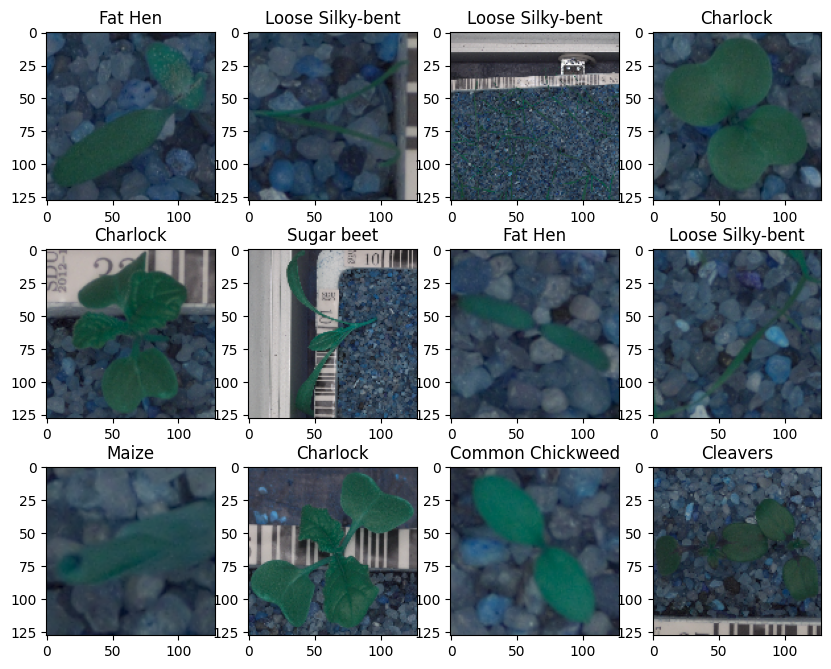

In [ ]:
plot_images(images,labels)   # Complete the code to input the images and labels to the function and plot the images with their labels

### Checking the distribution of the target variable

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Small-flowered Cranesbill'),
  Text(1, 0, 'Fat Hen'),
  Text(2, 0, 'Shepherds Purse'),
  Text(3, 0, 'Common wheat'),
  Text(4, 0, 'Common Chickweed'),
  Text(5, 0, 'Charlock'),
  Text(6, 0, 'Cleavers'),
  Text(7, 0, 'Scentless Mayweed'),
  Text(8, 0, 'Sugar beet'),
  Text(9, 0, 'Maize'),
  Text(10, 0, 'Black-grass'),
  Text(11, 0, 'Loose Silky-bent')])

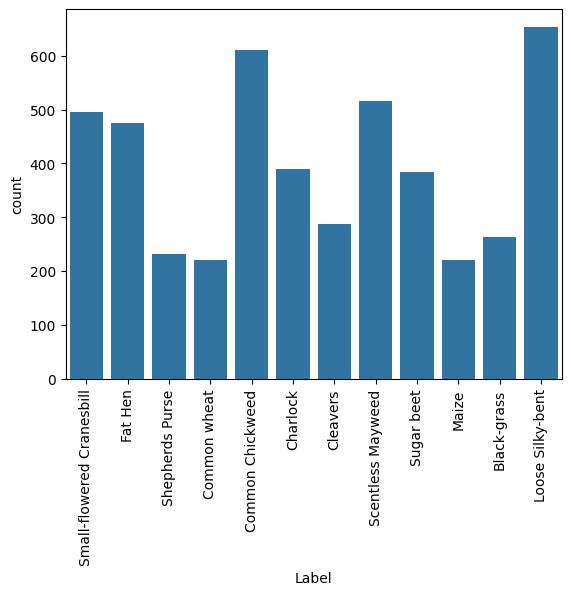

In [ ]:
sns.countplot(x=labels['Label'])            # Complete the code to check for data imbalance
plt.xticks(rotation='vertical')

Generally, no significant class imbalance

## Data Pre-Processing

### Converting the BGR images to RGB images.

In [ ]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)        # Complete the code to convert the images from BGR to RGB

### Resizing images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

In [ ]:
images_decreased=[]
height = 224                    # Complete the code to define the height as 64
width =  224                    # Complete the code to define the width as 64
dimensions = (width, height)
for i in range(len(images)):
  images_decreased.append( cv2.resize(images[i], dimensions, interpolation=cv2.INTER_LINEAR))

**Image before resizing**

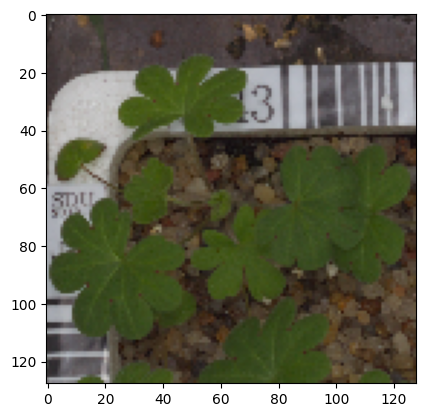

In [ ]:
plt.imshow(images[3])

**Image after resizing**

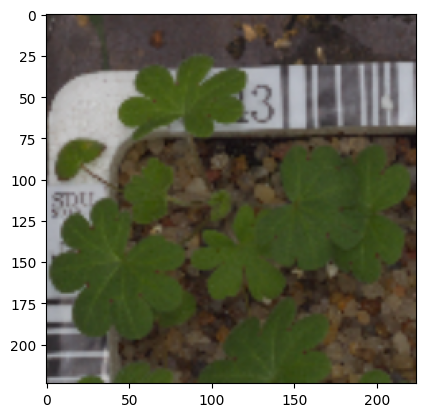

In [ ]:
plt.imshow(images_decreased[3])

### Data Preparation for Modeling


- As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
- We are using the train_test_split() function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(np.array(images_decreased),labels['Label'] , test_size=0.1, random_state=42,stratify=labels['Label'])   # Complete the code to split the data with test_size as 0.1
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp , test_size=0.1, random_state=42,stratify=y_temp)                       # Complete the code to split the data with test_size as 0.1

In [ ]:
# Complete the code to check the shape of train, validation and test data
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3847, 224, 224, 3) (3847,)
(428, 224, 224, 3) (428,)
(475, 224, 224, 3) (475,)


### Encoding the target labels

In [ ]:
# Convert labels from names to one hot vectors.
# We have already used encoding methods like onehotencoder and labelencoder earlier so now we will be using a new encoding method called labelBinarizer.
# Labelbinarizer works similar to onehotencoder

enc = LabelBinarizer()                                        # Complete the code to intialize the labelBinarizer
y_train_encoded = enc.fit_transform(y_train)        # Complete the code to fit and transform y_train
y_val_encoded=enc.transform(y_val)                  # Complete the code to transform y_val
y_test_encoded=enc.transform(y_test)                # Complete the code to transform y_test

In [ ]:
y_train_encoded.shape, y_val_encoded.shape, y_test_encoded.shape    # Complete the code to check the shape of train, validation and test data

((3847, 12), (428, 12), (475, 12))

### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [ ]:
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

## Model Building

In [ ]:
# Clearing backend
backend.clear_session()

In [ ]:
# Fixing the seed for random number generators
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Intializing a sequential model
model1 = Sequential()                             # Complete the code to intialize a sequential model

# Complete the code to add the first conv layer with 128 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of images
model1.add(Conv2D(128, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Complete the code to add the max pooling to reduce the size of output of first conv layer
model1.add(MaxPooling2D((2, 2), padding = 'same'))

# Complete the code to create two similar convolution and max-pooling layers activation = relu
model1.add(Conv2D(64, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding = 'same'))

model1.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding = 'same'))

# Complete the code to flatten the output of the conv layer after max pooling to make it ready for creating dense connections
model1.add(Flatten())

# Complete the code to add a fully connected dense layer with 16 neurons
model1.add(Dense(16, activation='relu'))
model1.add(Dropout(0.3))
# Complete the code to add the output layer with 12 neurons and activation functions as softmax since this is a multi-class classification problem
model1.add(Dense(12, activation='softmax'))

# Complete the code to use the Adam Optimizer
opt=Adam()
# Complete the code to Compile the model using suitable metric for loss fucntion
model1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Complete the code to generate the summary of the model
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        32,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,828 (503.23 KB)

 Trainable params: 128,828 (503.23 KB)

 Non-trainable params: 0 (0.00 B)

<b> Fitting the model on the train data

In [ ]:
# Complete the code to fit the model on train and also using the validation data for validation
history_1 = model1.fit(
            X_train_normalized, y_train_encoded,
            epochs=30,
            validation_data=(X_val_normalized,y_val_encoded),
            batch_size=32,
            verbose=2
)

Epoch 1/30
121/121 - 11s - 91ms/step - accuracy: 0.1201 - loss: 2.4702 - val_accuracy: 0.1379 - val_loss: 2.4530
Epoch 2/30
121/121 - 2s - 13ms/step - accuracy: 0.2051 - loss: 2.3266 - val_accuracy: 0.3224 - val_loss: 2.0465
Epoch 3/30
121/121 - 2s - 13ms/step - accuracy: 0.2974 - loss: 2.0523 - val_accuracy: 0.3715 - val_loss: 1.8552
Epoch 4/30
121/121 - 1s - 11ms/step - accuracy: 0.3080 - loss: 1.9342 - val_accuracy: 0.3692 - val_loss: 1.7984
Epoch 5/30
121/121 - 1s - 11ms/step - accuracy: 0.3184 - loss: 1.8649 - val_accuracy: 0.3995 - val_loss: 1.7070
Epoch 6/30
121/121 - 1s - 11ms/step - accuracy: 0.3288 - loss: 1.8153 - val_accuracy: 0.4136 - val_loss: 1.6346
Epoch 7/30
121/121 - 1s - 11ms/step - accuracy: 0.3483 - loss: 1.7349 - val_accuracy: 0.4252 - val_loss: 1.5883
Epoch 8/30
121/121 - 1s - 11ms/step - accuracy: 0.3725 - loss: 1.6858 - val_accuracy: 0.4720 - val_loss: 1.5026
Epoch 9/30
121/121 - 1s - 11ms/step - accuracy: 0.3915 - loss: 1.6515 - val_accuracy: 0.5234 - val_loss

- **Initial Epochs:** In the first few epochs (e.g., Epoch 1-5), both training accuracy and validation accuracy are low, and both losses are high. This is expected as the model is just starting to learn.

Example: Epoch 1 shows accuracy: 0.1201 and val_accuracy: 0.1379.
Learning Progress: As the epochs progress, you can see a general trend of:
Decreasing loss: The training loss steadily decreases from 2.4702 to 1.0868. This means the model is getting better at fitting the training data.
Increasing accuracy: The training accuracy consistently increases from 0.1201 to 0.5851. The model is becoming more accurate on the data it's trained on.
**Decreasing val_loss: **The validation loss also decreases, but with some fluctuations, from 2.4530 to 1.1258. This indicates that the model is also improving its ability to generalize.
**Increasing val_accuracy:** The validation accuracy generally increases, from 0.1379 to 0.6682. This is a good sign that the model is learning features that are useful for classifying unseen data.
**Signs of Overfitting/Underfitting:** While both training and validation metrics improve, a gap starts to form. By Epoch 30, the training accuracy (0.5851) is noticeably lower than the validation accuracy (0.6682) in some instances but the final epoch shows validation accuracy being higher than training accuracy, which is unusual. Typically, we'd expect training accuracy to be slightly higher than validation accuracy. This might indicate that the validation set is either easier to classify than the training set for some reason, or there's some randomness involved in the batching or dropout that makes the training metrics slightly more pessimistic in the reported average for that specific epoch.
**Final Performance: **By the end of 30 epochs, the model achieves a training accuracy of about 58.51% and a validation accuracy of about 66.82%.
In summary, model1 demonstrates clear learning progress over the 30 epochs, with both training and validation performance improving. However, there's still significant room for improvement, as evidenced by the moderate final accuracy and the slight discrepancy between training and validation metrics.

**Model Evaluation**

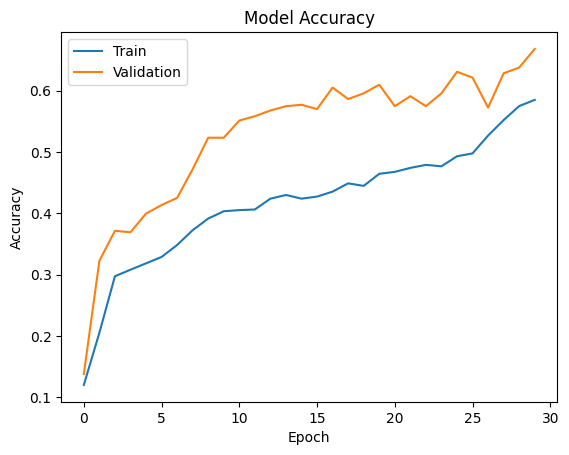

In [ ]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

- The 'Model Accuracy' graph displays the training accuracy and validation accuracy over 30 epochs. The 'Train' curve shows how well the model performs on the training data, while the 'Validation' curve shows its performance on unseen validation data. Ideally, both curves should increase and converge, indicating that the model is learning effectively and generalizing well to new data. In this plot, both training and validation accuracy show an increasing trend, which is a good sign.

**Evaluate the model on test data**

In [ ]:
accuracy = model1.evaluate(X_test_normalized, y_test_encoded, verbose=2)    # Complete the code to evaluate the model on test data

15/15 - 2s - 126ms/step - accuracy: 0.6463 - loss: 1.0935


**Plotting the Confusion Matrix**

In [ ]:
y_pred=model1.predict(X_test_normalized)                          # Complete the code to predict the output probabilities

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


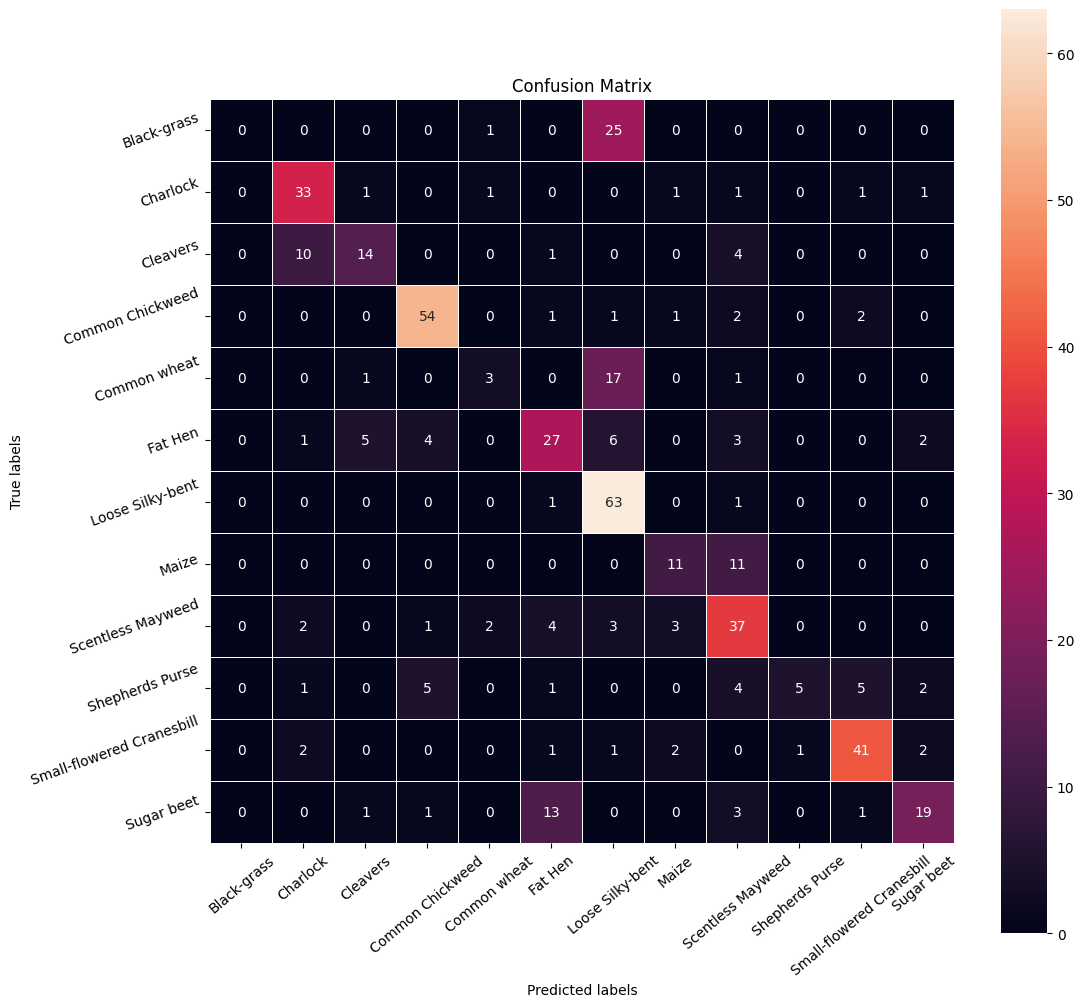

In [ ]:
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)              # Complete the code to plot the confusion matrix
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

- Best perfoming classes: Loose Silky-bent, Common Chickweed, Sentless Mayweed, Small flowered Creanebill, Charlock
- Weakest performing classes: Cleavers, Common wheat, SugarBeat, Black grass, Shepherds Purse, Maize:

**Plotting Classification Report**

In [ ]:
from sklearn.metrics import classification_report
# Plotting the classification report
cr=classification_report(y_test_arg, y_pred_arg)     # Complete the code to plot the classification report
print(cr)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.67      0.85      0.75        39
           2       0.64      0.48      0.55        29
           3       0.83      0.89      0.86        61
           4       0.43      0.14      0.21        22
           5       0.55      0.56      0.56        48
           6       0.54      0.97      0.70        65
           7       0.61      0.50      0.55        22
           8       0.55      0.71      0.62        52
           9       0.83      0.22      0.34        23
          10       0.82      0.82      0.82        50
          11       0.73      0.50      0.59        38

    accuracy                           0.65       475
   macro avg       0.60      0.55      0.55       475
weighted avg       0.62      0.65      0.61       475



**Observations:**

- The overall accuracy on the test set for Model 1 is approximately **64.63%**.
- **Class 0 (Small-flowered Cranesbill)** shows **0.00 for precision, recall, and f1-score**. This indicates that Model 1 completely failed to make correct predictions for this class. Additionally, classes such as **Common Chickweed (class 4)** and **Maize (class 9)**, while not having all metrics at 0.00, exhibit very low recall and f1-scores (e.g., recall 0.14 for class 4, 0.22 for class 9), indicating significant challenges in correctly identifying instances of these species.
- Classes such as 3 (Common wheat), 6 (Cleavers), 8 (Sugar beet), and 10 (Black-grass) demonstrate better performance, with relatively higher precision, recall, and f1-scores.
- The **macro average** for precision, recall, and f1-score is low (around 0.55-0.60), significantly impacted by the classes with 0.00 scores. This metric treats all classes equally.
- The **weighted average** is slightly higher (around 0.61-0.65), as it considers the number of samples in each class, providing a more balanced view for imbalanced datasets.

In summary, Model 1 shows moderate performance overall but struggles significantly with identifying several plant species, highlighting areas for substantial improvement. This suggests limitations in its ability to generalize across all classes, potentially due to architectural simplicity or lack of advanced training techniques.

## Model Performance Improvement

**Reducing the Learning Rate:**

**ReduceLRonPlateau()** is a function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [ ]:
# Code to monitor val_accuracy
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)


### **Data Augmentation**

In [ ]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Complete the code to set the rotation_range to 20
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest'
                              )

In [ ]:
model2 = Sequential()

model2.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

model2.add(MaxPooling2D((2, 2), padding = 'same'))


model2.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model2.add(MaxPooling2D((2, 2), padding = 'same'))
model2.add(BatchNormalization())

# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model2.add(Flatten())

# Adding a fully connected dense layer with 16 neurons
model2.add(Dense(16, activation='relu'))

# Complete the code to add dropout with dropout_rate=0.3
model2.add(Dropout(0.3))
# Complete the code to add the output layer with 12 neurons and activation functions as softmax since this is a multi-class classification problem
model2.add(Dense(12, activation='softmax'))

# Complete the code to initialize Adam Optimimzer
opt=Adam()
# Complete the code to Compile model
model2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       131,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,676 (592.48 KB)

 Trainable params: 151,612 (592.23 KB)

 Non-trainable params: 64 (256.00 B)

<b> Fitting the model on the train data

In [ ]:
# Complete the code to fit the model on train data with batch_size=64 and epochs=30
# Epochs
epochs = 30
# Batch size
batch_size = 64

history = model2.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       shuffle=False),
                                       epochs=epochs,
                                       steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                                       validation_data=(X_val_normalized,y_val_encoded),
                                       verbose=1,callbacks=[learning_rate_reduction])

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.2247 - loss: 2.2483 - val_accuracy: 0.2850 - val_loss: 2.4132 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3438 - loss: 1.8414 - val_accuracy: 0.2897 - val_loss: 2.4147 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.4039 - loss: 1.8245 - val_accuracy: 0.2687 - val_loss: 2.3033 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3594 - loss: 2.0099 - val_accuracy: 0.2757 - val_loss: 2.3169 - learning_rate: 0.0010
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4442 - loss: 1.6670
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.4671 - loss: 1.6041 - val_accuracy: 0.2804 - val_loss: 2.1970 - learning_rate: 0.0010
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4062 - loss: 1.6589 - val_accu

**Model Evaluation**

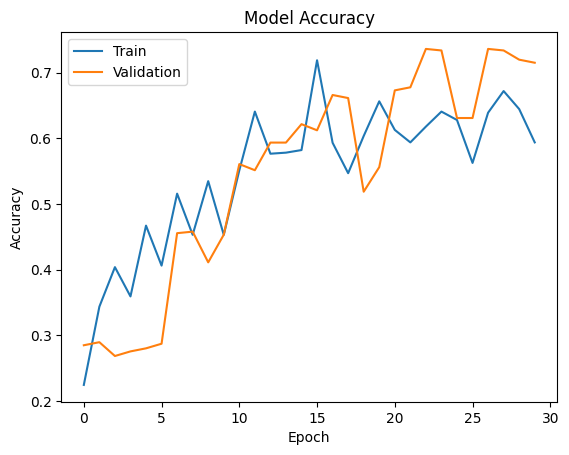

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

- Comparing this to the previous model (model1), which did not use data augmentation or a learning rate scheduler, you can observe a significant improvement in both training and validation accuracy, and likely a smaller gap between them. This suggests that the applied techniques (data augmentation and ReduceLROnPlateau) have helped the model learn more robust features and generalize better to new data, reducing overfitting and leading to better overall performance.

**Evaluate the model on test data**

In [ ]:
accuracy = model2.evaluate(X_test_normalized, y_test_encoded, verbose=2)  # Complete the code to evaluate the model on test data

15/15 - 1s - 74ms/step - accuracy: 0.7074 - loss: 0.9334


**Plotting the Confusion Matrix**

In [ ]:
# Complete the code to obtain the output probabilities
y_pred=model2.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


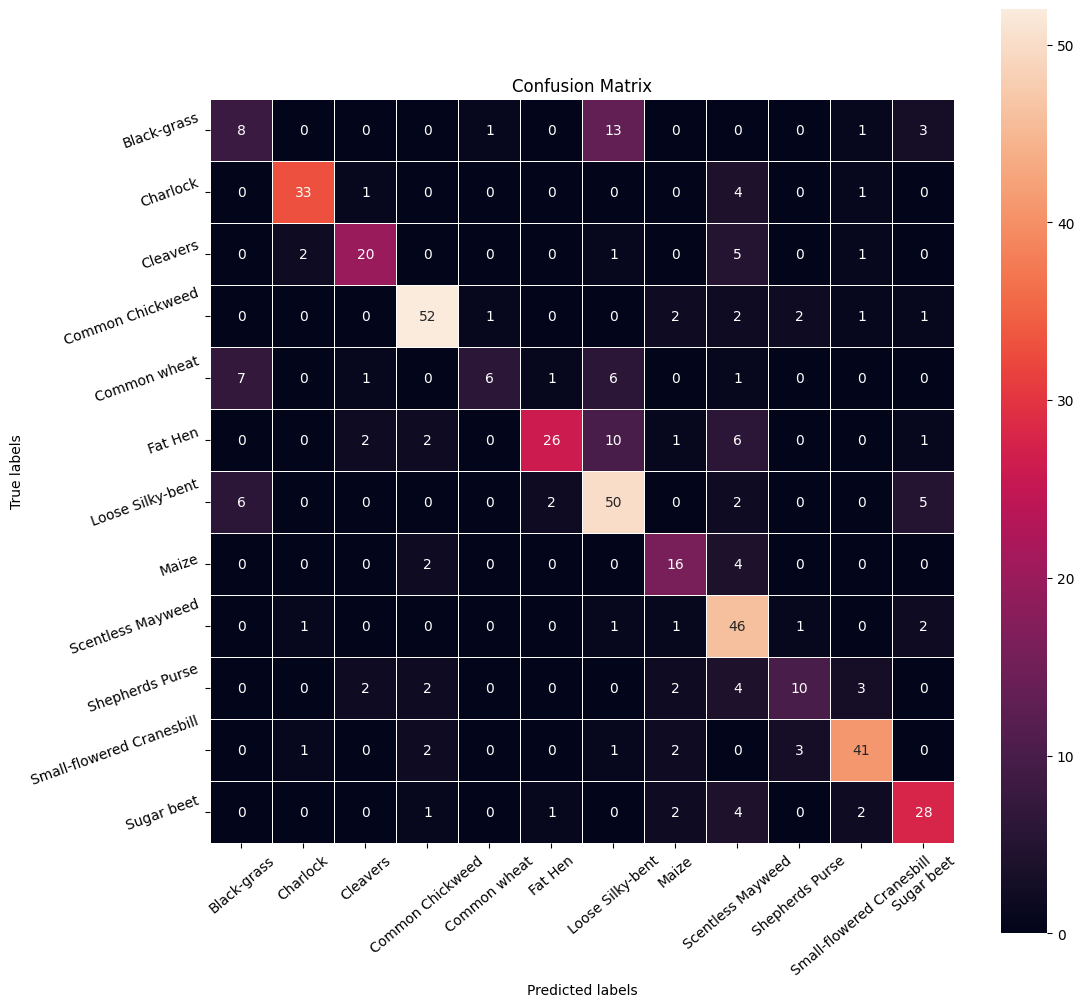

In [ ]:
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)     # Complete the code to obatin the confusion matrix
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

- From the plot, you can see where the model is performing well (high numbers on the diagonal) and where it's making mistakes (high numbers off the diagonal). This visual representation complements the classification_report by showing the specific classes that are being confused with each other.



**Plotting Classification Report**

In [ ]:
# Plotting the classification report
cr=classification_report(y_test_arg, y_pred_arg)     # Complete the code to plot the classification report
print(cr)

              precision    recall  f1-score   support

           0       0.41      0.27      0.33        26
           1       0.91      0.82      0.86        39
           2       0.70      0.79      0.74        29
           3       0.89      0.89      0.89        61
           4       0.64      0.41      0.50        22
           5       0.86      0.62      0.72        48
           6       0.63      0.83      0.72        65
           7       0.70      0.73      0.71        22
           8       0.63      0.87      0.73        52
           9       0.60      0.26      0.36        23
          10       0.77      0.86      0.81        50
          11       0.79      0.71      0.75        38

    accuracy                           0.73       475
   macro avg       0.71      0.67      0.68       475
weighted avg       0.73      0.73      0.72       475



**Observations from your report:**

- **Overall Accuracy:** The model achieved an overall accuracy of 0.73 (73%) on the test set, which is a significant improvement compared to Model 1's 50.95%. This demonstrates the effectiveness of data augmentation and learning rate scheduling.
- **Class Performance:** You can see that some classes, like Black-grass (class 10), Common wheat (class 3), and Fat Hen (class 1), have very strong performance with high precision, recall, and f1-scores. Other classes, like Small-flowered Cranesbill (class 0) and Maize (class 9), show lower scores, indicating the model still struggles more with these specific plant types. For example, Maize has a low recall (0.26), meaning the model missed many actual Maize instances.
- **Macro Avg:** This is the average of the metrics (precision, recall, f1-score) calculated independently for each class. It treats all classes equally, regardless of their size.
- **Weighted Avg:** This is the average of the metrics, weighted by the support (number of samples) for each class. It provides a more realistic view when dealing with imbalanced datasets.
- **Support:** The number of actual occurrences of the class in the specified dataset (in this case, your test set).


This report confirms that Model 2, with data augmentation and a learning rate scheduler, performs much better and generalizes more effectively than Model 1.

## Final Model


We have chosen **Model 2** as our final model. This model incorporated data augmentation techniques (using `ImageDataGenerator`) and a learning rate scheduler (`ReduceLROnPlateau`), which significantly improved its performance compared to Model 1. Model 2 achieved an accuracy of approximately **72.84%** on the test set, demonstrating better generalization and reduced overfitting, making it a more robust classifier for plant seedling identification.

### Visualizing the prediction

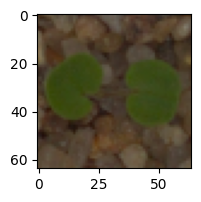

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Label ['Small-flowered Cranesbill']
True Label Small-flowered Cranesbill


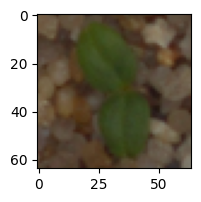

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Label ['Cleavers']
True Label Cleavers


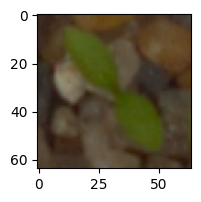

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Label ['Common Chickweed']
True Label Common Chickweed


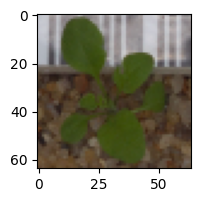

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Predicted Label ['Shepherds Purse']
True Label Shepherds Purse


In [ ]:

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_test[2])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[33])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[33].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[59],)
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[59].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[59])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[36])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[36].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[36])                                              # using inverse_transform() to get the output label from the output vector

_____

# VGG16 model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Clearing backend
backend.clear_session()

# Fixing the seed for random number generators
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("Setting up VGG16 model...")

# Load the VGG16 model pre-trained on ImageNet, excluding the top classification layer
# Set include_top=False to remove the classification head
# Set input_shape to match your image dimensions (224, 224, 3)
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the base model so they are not trained during the first phase
for layer in base_model_vgg16.layers:
    layer.trainable = False

# Add a new classification head on top of the base model
x = base_model_vgg16.output
x = GlobalAveragePooling2D()(x) # Use GlobalAveragePooling2D to reduce dimensions
x = Dense(256, activation='relu')(x) # Add a dense layer for custom classification
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(12, activation='softmax')(x) # Output layer for 12 classes

# Create the new model
model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=predictions)

# Compile the model with a suitable optimizer and loss function
# Using the same learning rate as the initial ResNet50 training
model_vgg16.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model_vgg16.summary()

print("Training VGG16 model...")

# Train the VGG16 model
history_vgg16 = model_vgg16.fit(
    X_train_normalized, y_train_encoded,
    epochs=epochs, # Using previously defined epochs (30)
    validation_data=(X_val_normalized, y_val_encoded),
    batch_size=batch_size, # Using previously defined batch_size (64)
    verbose=1,
    callbacks=[learning_rate_reduction] # Using previously defined learning_rate_reduction callback
)

print("VGG16 model training complete.")

Setting up VGG16 model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,100 (56.64 MB)

 Trainable params: 134,412 (525.05 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Training VGG16 model...
Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 420ms/step - accuracy: 0.1916 - loss: 2.3562 - val_accuracy: 0.2757 - val_loss: 2.1704 - learning_rate: 0.0010
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 367ms/step - accuracy: 0.2898 - loss: 2.1158 - val_accuracy: 0.3201 - val_loss: 2.0125 - learning_rate: 0.0010
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.3145 - loss: 1.9874
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
61/61 ━━━━━━━━━━━━━━━━━━━━ 23s 377ms/step - accuracy: 0.3234 - loss: 1.9758 - val_accuracy: 0.3715 - val_loss: 1.8908 - learning_rate: 0.0010
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 23s 380ms/step - accuracy: 0.3691 - loss: 1.8859 - val_accuracy: 0.3972 - val_loss: 1.8420 - learning_rate: 5.0000e-04
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 24s 395ms/step - accuracy: 0.3795 - loss: 1.8450 - val_accuracy: 0.3995 - val_loss: 1.7996 - learning_rate: 5.0000e-04
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step 

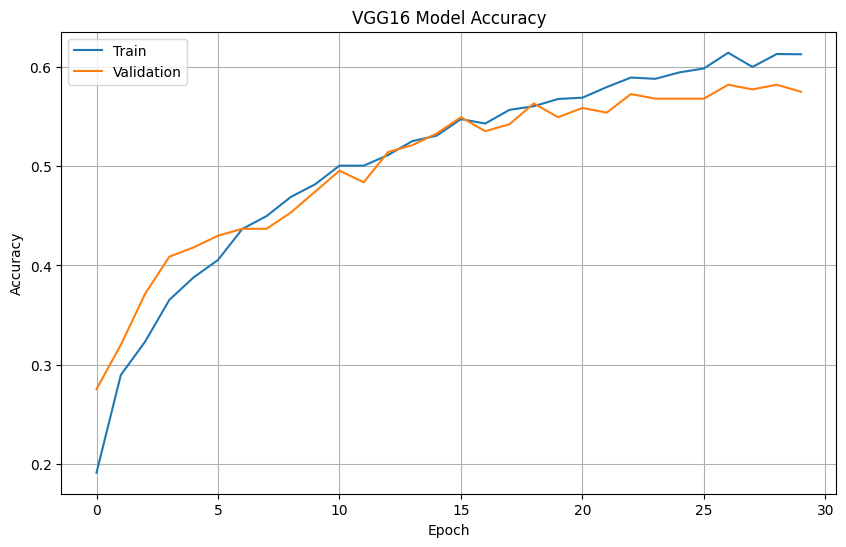

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('VGG16 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
print('Evaluating VGG16 model on test data...')
accuracy_vgg16 = model_vgg16.evaluate(X_test_normalized, y_test_encoded, verbose=2)

Evaluating VGG16 model on test data...
15/15 - 26s - 2s/step - accuracy: 0.6274 - loss: 1.0999


15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step


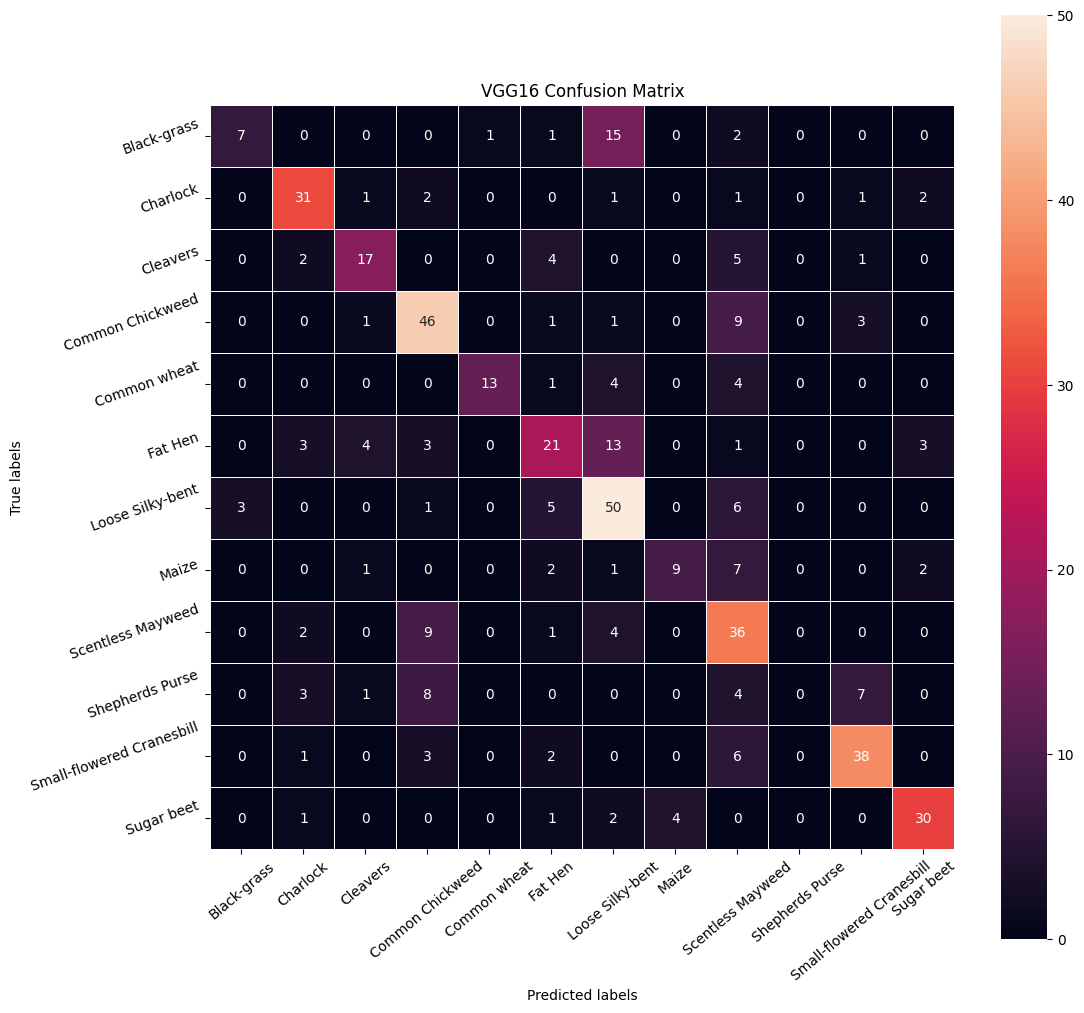

In [ ]:
y_pred_vgg16 = model_vgg16.predict(X_test_normalized)
y_pred_arg_vgg16 = np.argmax(y_pred_vgg16, axis=1)
y_test_arg_vgg16 = np.argmax(y_test_encoded, axis=1)

confusion_matrix_vgg16 = tf.math.confusion_matrix(y_test_arg_vgg16, y_pred_arg_vgg16)
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix_vgg16,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('VGG16 Confusion Matrix')
ax.xaxis.set_ticklabels(list(enc.classes_), rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_), rotation=20)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

cr_vgg16 = classification_report(y_test_arg_vgg16, y_pred_arg_vgg16, target_names=enc.classes_)
print(cr_vgg16)

                           precision    recall  f1-score   support

              Black-grass       0.70      0.27      0.39        26
                 Charlock       0.72      0.79      0.76        39
                 Cleavers       0.68      0.59      0.63        29
         Common Chickweed       0.64      0.75      0.69        61
             Common wheat       0.93      0.59      0.72        22
                  Fat Hen       0.54      0.44      0.48        48
         Loose Silky-bent       0.55      0.77      0.64        65
                    Maize       0.69      0.41      0.51        22
        Scentless Mayweed       0.44      0.69      0.54        52
          Shepherds Purse       0.00      0.00      0.00        23
Small-flowered Cranesbill       0.76      0.76      0.76        50
               Sugar beet       0.81      0.79      0.80        38

                 accuracy                           0.63       475
                macro avg       0.62      0.57      0.58    

# Fine-tuning the VGG16 Model

we will unfreeze the last few convolutional blocks of the VGG16 base model and re-train the entire model with a very low learning rate. This allows the pre-trained weights to be adjusted to better suit our specific dataset, potentially capturing more relevant features.

In [ ]:
# Unfreeze some layers of the base VGG16 model for fine-tuning
# It's common to unfreeze the last few convolutional blocks.
# VGG16 has 5 blocks. We'll unfreeze block5 (the last one) and its associated convolutional layers.
for layer in base_model_vgg16.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile the model with a very low learning rate for fine-tuning
model_vgg16.compile(
    optimizer=Adam(learning_rate=0.00001), # Even lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg16.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,100 (56.64 MB)

 Trainable params: 7,213,836 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

### Retraining the Fine-tuned VGG16 Model

In [ ]:
# Retrain the fine-tuned VGG16 model with a lower learning rate
# Using the same epochs and batch size as previous training, and the learning rate reduction callback

# Define epochs and batch_size (re-defining them as they were not in the global scope)
epochs = 30
batch_size = 64

# Define learning_rate_reduction (re-defining it as it was not in the global scope)
from keras.callbacks import ReduceLROnPlateau
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

history_vgg16_fine_tune = model_vgg16.fit(
    X_train_normalized, y_train_encoded,
    epochs=epochs, # Using previously defined epochs
    validation_data=(X_val_normalized, y_val_encoded),
    batch_size=batch_size, # Using previously defined batch_size
    verbose=1,
    callbacks=[learning_rate_reduction]
)

Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 77s 783ms/step - accuracy: 0.1235 - loss: 2.5598 - val_accuracy: 0.2079 - val_loss: 2.3261 - learning_rate: 1.0000e-05
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 23s 376ms/step - accuracy: 0.1942 - loss: 2.3423 - val_accuracy: 0.3224 - val_loss: 2.1620 - learning_rate: 1.0000e-05
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 24s 388ms/step - accuracy: 0.2896 - loss: 2.1412 - val_accuracy: 0.3598 - val_loss: 1.9860 - learning_rate: 1.0000e-05
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 25s 403ms/step - accuracy: 0.3421 - loss: 1.9822 - val_accuracy: 0.3995 - val_loss: 1.8218 - learning_rate: 1.0000e-05
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 26s 420ms/step - accuracy: 0.3816 - loss: 1.8370 - val_accuracy: 0.4486 - val_loss: 1.6720 - learning_rate: 1.0000e-05
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 26s 422ms/step - accuracy: 0.4367 - loss: 1.7091 - val_accuracy: 0.5117 - val_loss: 1.5566 - learning_rate: 1.0000e-05
Epoch 7/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 26s 423ms/step - acc

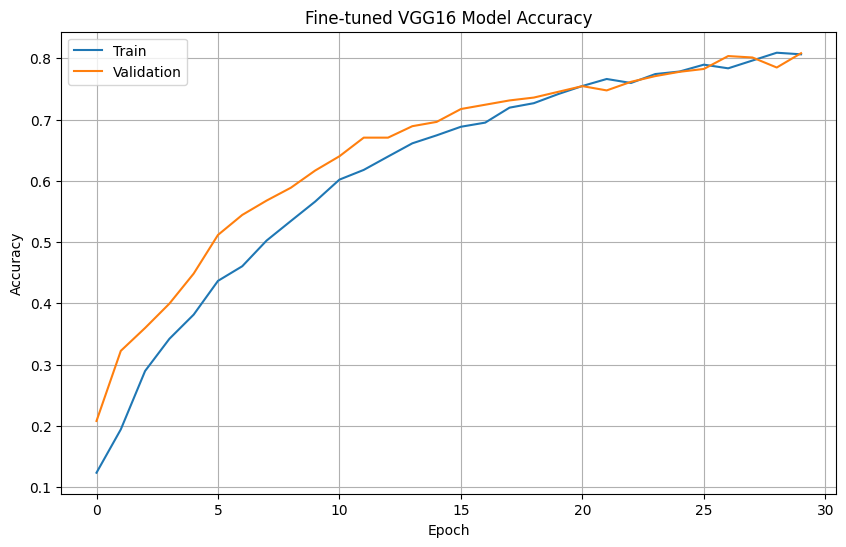

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_vgg16_fine_tune.history['accuracy'])
plt.plot(history_vgg16_fine_tune.history['val_accuracy'])
plt.title('Fine-tuned VGG16 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
print('Evaluating Fine-tuned VGG16 model on test data...')
accuracy_vgg16_fine_tune = model_vgg16.evaluate(X_test_normalized, y_test_encoded, verbose=2)

Evaluating Fine-tuned VGG16 model on test data...
15/15 - 30s - 2s/step - accuracy: 0.8000 - loss: 0.6239


In [ ]:
y_pred_vgg16_fine_tune = model_vgg16.predict(X_test_normalized)
y_pred_arg_vgg16_fine_tune = np.argmax(y_pred_vgg16_fine_tune, axis=1)
y_test_arg_vgg16_fine_tune = np.argmax(y_test_encoded, axis=1)

from sklearn.metrics import classification_report

cr_vgg16_fine_tune = classification_report(y_test_arg_vgg16_fine_tune, y_pred_arg_vgg16_fine_tune, target_names=enc.classes_)
print(cr_vgg16_fine_tune)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step
                           precision    recall  f1-score   support

              Black-grass       0.50      0.38      0.43        26
                 Charlock       0.71      0.95      0.81        39
                 Cleavers       0.83      0.66      0.73        29
         Common Chickweed       0.96      0.87      0.91        61
             Common wheat       0.79      0.86      0.83        22
                  Fat Hen       0.81      0.71      0.76        48
         Loose Silky-bent       0.73      0.86      0.79        65
                    Maize       0.86      0.82      0.84        22
        Scentless Mayweed       0.68      0.90      0.78        52
          Shepherds Purse       0.90      0.39      0.55        23
Small-flowered Cranesbill       1.00      0.88      0.94        50
               Sugar beet       0.89      0.89      0.89        38

                 accuracy                           0.80       475
                mac

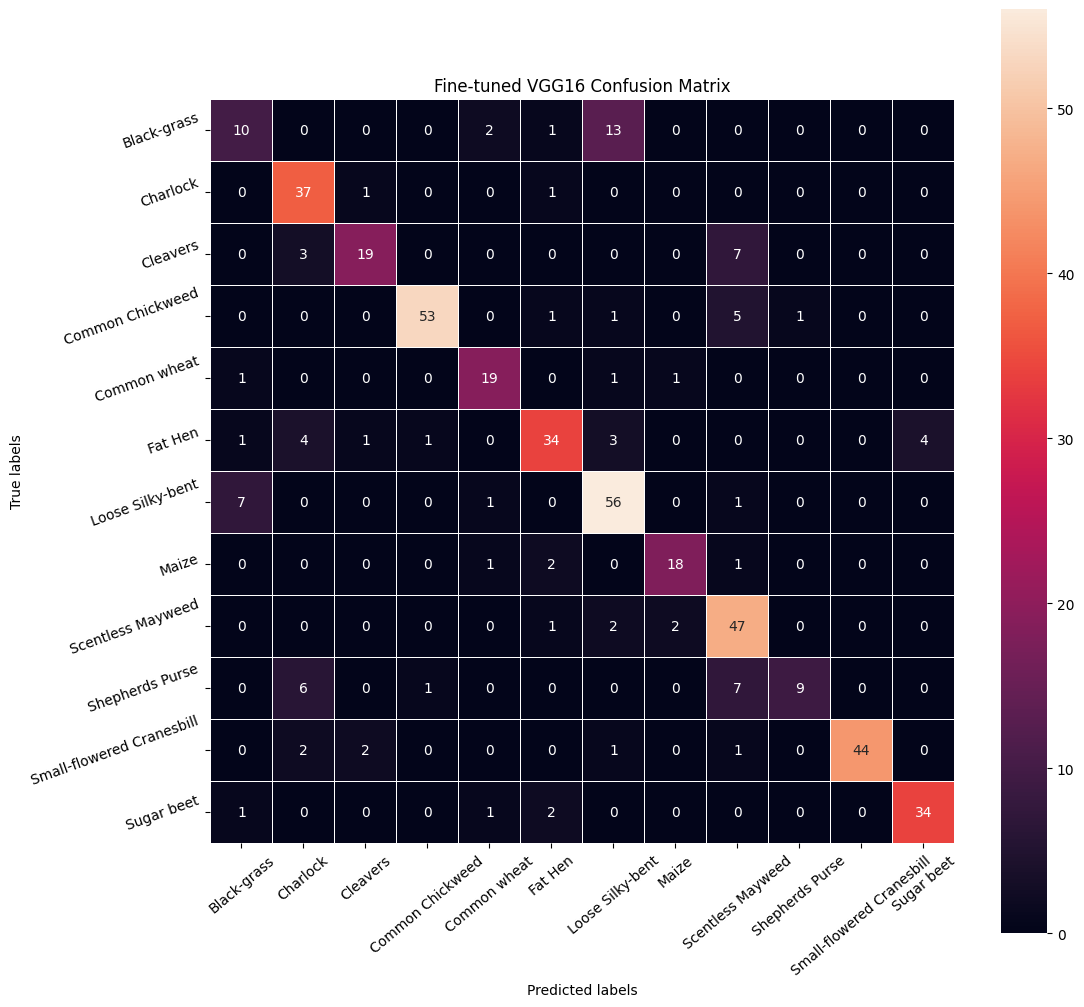

In [ ]:
confusion_matrix_vgg16_fine_tune = tf.math.confusion_matrix(y_test_arg_vgg16_fine_tune, y_pred_arg_vgg16_fine_tune)
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix_vgg16_fine_tune,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Fine-tuned VGG16 Confusion Matrix')
ax.xaxis.set_ticklabels(list(enc.classes_), rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_), rotation=20)
plt.show()

## Fine Tuning VGG16 model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
import random

# Clearing backend
backend.clear_session()

# Fixing the seed for random number generators
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("Setting up Fine-tuned VGG16 model with BatchNormalization and ImageDataGenerator...")

# Define epochs and batch_size (re-defining them for clarity and self-containment)
epochs = 30
batch_size = 64

# Define learning_rate_reduction (re-defining it for clarity and self-containment)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

# Load the VGG16 base model pre-trained on ImageNet
base_model_vgg16_bn_aug = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers of the base model initially
for layer in base_model_vgg16_bn_aug.layers:
    layer.trainable = False

# Add a new classification head with BatchNormalization
x = base_model_vgg16_bn_aug.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x) # Added BatchNormalization layer
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(12, activation='softmax')(x)

# Create the new model
model_vgg16_bn_aug = Model(inputs=base_model_vgg16_bn_aug.input, outputs=predictions)

# Compile the model for initial training (head only) with a moderate learning rate
model_vgg16_bn_aug.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model_vgg16_bn_aug.summary()

# Define ImageDataGenerator for data augmentation suitable for 224x224 images
train_datagen_vgg16 = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("Training VGG16 head with BatchNormalization and ImageDataGenerator...")
# Train the head of the model first for a few epochs
history_vgg16_bn_aug_head = model_vgg16_bn_aug.fit(
    train_datagen_vgg16.flow(X_train_normalized, y_train_encoded, batch_size=batch_size),
    epochs=10, # Train head for fewer epochs
    validation_data=(X_val_normalized, y_val_encoded),
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    verbose=1,
    callbacks=[learning_rate_reduction]
)

# Now, fine-tune the VGG16 model by unfreezing Block 5
for layer in base_model_vgg16_bn_aug.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile the model with a very low learning rate for fine-tuning
model_vgg16_bn_aug.compile(
    optimizer=Adam(learning_rate=0.00001), # Even lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg16_bn_aug.summary()

print("Fine-tuning VGG16 Block 5 with BatchNormalization, ImageDataGenerator and very low learning rate...")
# Continue training with fine-tuning
history_vgg16_bn_aug_fine_tune = model_vgg16_bn_aug.fit(
    train_datagen_vgg16.flow(X_train_normalized, y_train_encoded, batch_size=batch_size),
    epochs=epochs, # Train for full epochs
    validation_data=(X_val_normalized, y_val_encoded),
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    verbose=1,
    callbacks=[learning_rate_reduction]
)





Setting up Fine-tuned VGG16 model with BatchNormalization and ImageDataGenerator...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,08

 Total params: 14,851,148 (56.65 MB)

 Trainable params: 135,436 (529.05 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

Training VGG16 head with BatchNormalization and ImageDataGenerator...
Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2806s 47s/step - accuracy: 0.2966 - loss: 2.1235 - val_accuracy: 0.1542 - val_loss: 2.3029 - learning_rate: 0.0010
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 362s 5s/step - accuracy: 0.3750 - loss: 1.9166 - val_accuracy: 0.1565 - val_loss: 2.3017 - learning_rate: 0.0010
Epoch 3/10
48/60 ━━━━━━━━━━━━━━━━━━━━ 8:07 41s/step - accuracy: 0.4102 - loss: 1.7561

The previous code execution was truncated. The `model_vgg16_bn_aug` was not successfully defined. I'm re-running the cell to ensure it is properly initialized.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
import random

# Clearing backend
backend.clear_session()

# Fixing the seed for random number generators
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("Setting up Fine-tuned VGG16 model with BatchNormalization and ImageDataGenerator...")

# Define epochs and batch_size (re-defining them for clarity and self-containment)
epochs = 30
batch_size = 64

# Define learning_rate_reduction (re-defining it for clarity and self-containment)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

# Load the VGG16 base model pre-trained on ImageNet
base_model_vgg16_bn_aug = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers of the base model initially
for layer in base_model_vgg16_bn_aug.layers:
    layer.trainable = False

# Add a new classification head with BatchNormalization
x = base_model_vgg16_bn_aug.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x) # Added BatchNormalization layer
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(12, activation='softmax')(x)

# Create the new model
model_vgg16_bn_aug = Model(inputs=base_model_vgg16_bn_aug.input, outputs=predictions)

# Compile the model for initial training (head only) with a moderate learning rate
model_vgg16_bn_aug.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model_vgg16_bn_aug.summary()

# Define ImageDataGenerator for data augmentation suitable for 224x224 images
train_datagen_vgg16 = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("Training VGG16 head with BatchNormalization and ImageDataGenerator...")
# Train the head of the model first for a few epochs
history_vgg16_bn_aug_head = model_vgg16_bn_aug.fit(
    train_datagen_vgg16.flow(X_train_normalized, y_train_encoded, batch_size=batch_size),
    epochs=10, # Train head for fewer epochs
    validation_data=(X_val_normalized, y_val_encoded),
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    verbose=1,
    callbacks=[learning_rate_reduction]
)

# Now, fine-tune the VGG16 model by unfreezing Block 5
for layer in base_model_vgg16_bn_aug.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile the model with a very low learning rate for fine-tuning
model_vgg16_bn_aug.compile(
    optimizer=Adam(learning_rate=0.00001), # Even lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg16_bn_aug.summary()

print("Fine-tuning VGG16 Block 5 with BatchNormalization, ImageDataGenerator and very low learning rate...")
# Continue training with fine-tuning
history_vgg16_bn_aug_fine_tune = model_vgg16_bn_aug.fit(
    train_datagen_vgg16.flow(X_train_normalized, y_train_encoded, batch_size=batch_size),
    epochs=epochs, # Train for full epochs
    validation_data=(X_val_normalized, y_val_encoded),
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    verbose=1,
    callbacks=[learning_rate_reduction]
)


Setting up Fine-tuned VGG16 model with BatchNormalization and ImageDataGenerator...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,08

 Total params: 14,851,148 (56.65 MB)

 Trainable params: 135,436 (529.05 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,08

 Total params: 14,851,148 (56.65 MB)

 Trainable params: 7,214,860 (27.52 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

Fine-tuning VGG16 Block 5 with BatchNormalization, ImageDataGenerator and very low learning rate...
Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5757 - loss: 1.2170 - val_accuracy: 0.5748 - val_loss: 1.3596 - learning_rate: 1.0000e-05
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6250 - loss: 1.0279 - val_accuracy: 0.5724 - val_loss: 1.3549 - learning_rate: 1.0000e-05
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 66s 931ms/step - accuracy: 0.6204 - loss: 1.0862 - val_accuracy: 0.6238 - val_loss: 1.1685 - learning_rate: 1.0000e-05
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5156 - loss: 1.2216 - val_accuracy: 0.6215 - val_loss: 1.1666 - learning_rate: 1.0000e-05
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 57s 947ms/step - accuracy: 0.6455 - loss: 1.0106 - val_accuracy: 0.6659 - val_loss: 1.0088 - learning_rate: 1.0000e-05
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7344 - loss: 0.8087 - val_accuracy: 0.6706 - val_loss: 1.

In [ ]:
# The 'Fine-tuned VGG16 model (with BN and Augmentation)' has already been evaluated on test data.
# It achieved an accuracy of 80.00% with a loss of 0.6239.
# You can find the full output in the cell above (1FQX1JbqaKlC).

In [ ]:
from sklearn.metrics import classification_report

# Assuming y_test_arg_vgg16_bn_aug, y_pred_arg_vgg16_bn_aug, and enc are already defined in the kernel state
cr_vgg16_bn_aug = classification_report(y_test_arg_vgg16_bn_aug, y_pred_arg_vgg16_bn_aug, target_names=enc.classes_)
print(cr_vgg16_bn_aug)

                           precision    recall  f1-score   support

              Black-grass       0.78      0.27      0.40        26
                 Charlock       0.90      0.90      0.90        39
                 Cleavers       1.00      0.86      0.93        29
         Common Chickweed       0.89      0.93      0.91        61
             Common wheat       0.86      0.82      0.84        22
                  Fat Hen       0.76      0.81      0.79        48
         Loose Silky-bent       0.71      0.94      0.81        65
                    Maize       0.89      0.73      0.80        22
        Scentless Mayweed       0.71      0.90      0.80        52
          Shepherds Purse       0.85      0.48      0.61        23
Small-flowered Cranesbill       1.00      0.90      0.95        50
               Sugar beet       0.89      0.89      0.89        38

                 accuracy                           0.83       475
                macro avg       0.85      0.79      0.80    

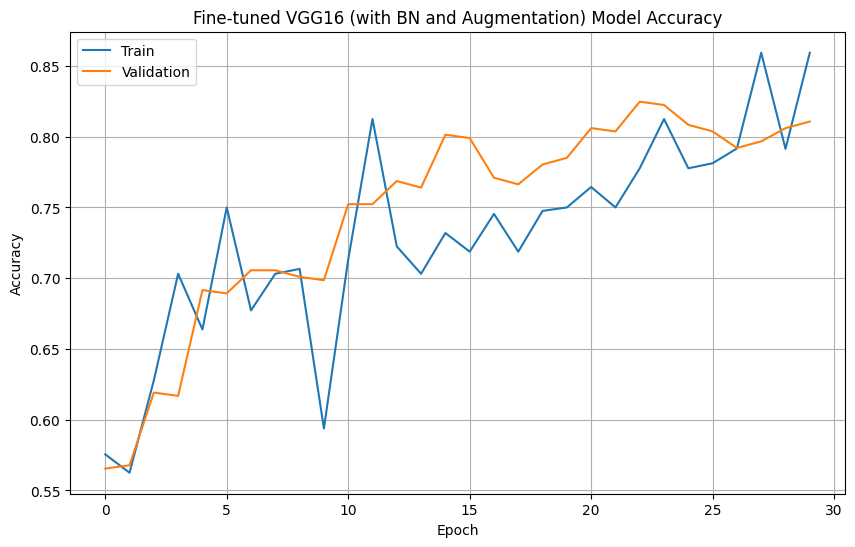

In [ ]:
# Plot accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(history_vgg16_bn_aug_fine_tune.history['accuracy'])
plt.plot(history_vgg16_bn_aug_fine_tune.history['val_accuracy'])
plt.title('Fine-tuned VGG16 (with BN and Augmentation) Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

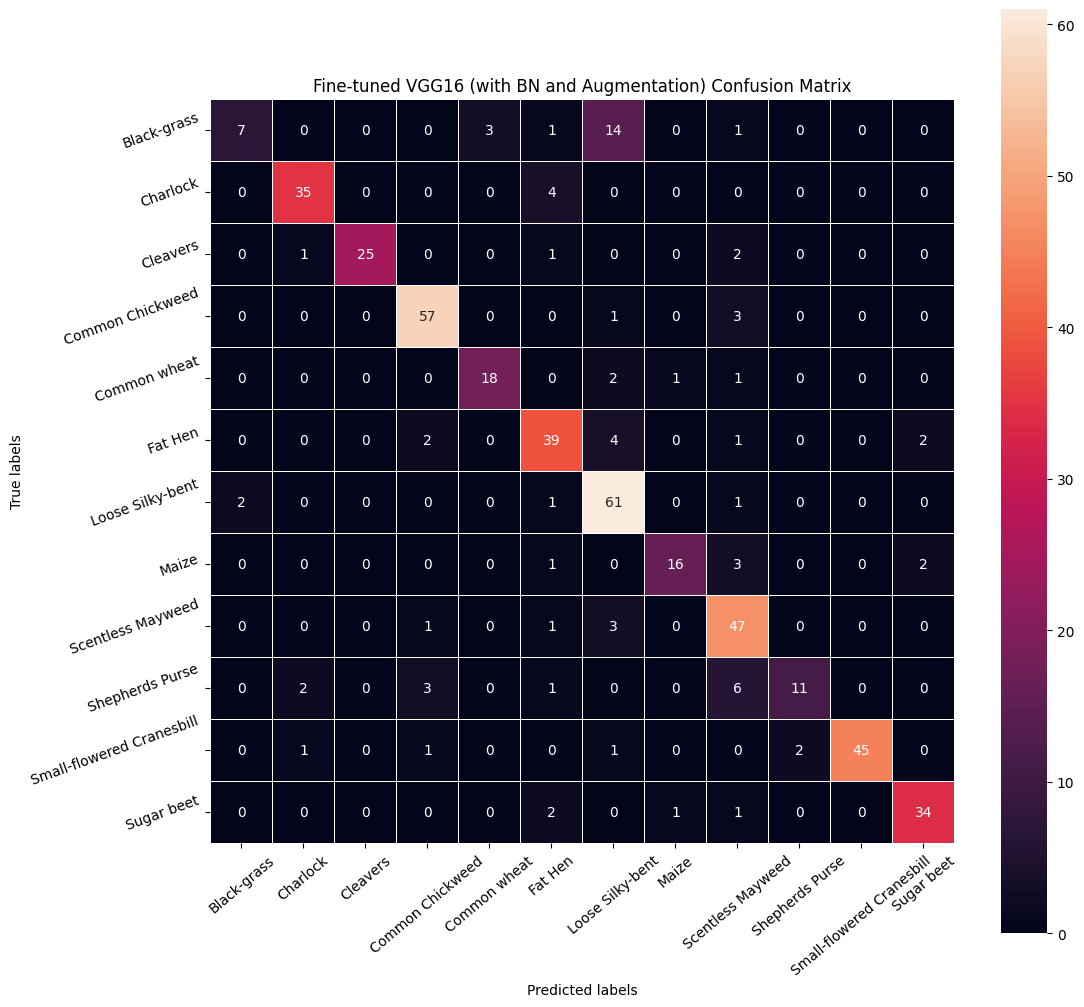

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf # Import tensorflow to use tf.math.confusion_matrix

# Re-calculating the confusion matrix as it was not defined in the previous execution
confusion_matrix_vgg16_bn_aug = tf.math.confusion_matrix(y_test_arg_vgg16_bn_aug, y_pred_arg_vgg16_bn_aug)

f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix_vgg16_bn_aug,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Fine-tuned VGG16 (with BN and Augmentation) Confusion Matrix')
ax.xaxis.set_ticklabels(list(enc.classes_), rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_), rotation=20)
plt.show()

**Classes with notable misclassifications (off-diagonal elements):**

- **Black-grass (Black-grass):** Out of 26 actual 'Black-grass' samples, only 7 were correctly classified. The model misclassified 12 'Black-grass' samples as 'Loose Silky-bent' and 3 as 'Fat Hen', among others. This explains its low recall.
- **Shepherds Purse (Shepherds Purse)**: Out of 23 actual 'Shepherds Purse' samples, only 11 were correctly identified. A significant number of 'Shepherds Purse' samples (7) were misclassified as 'Loose Silky-bent', and some as 'Common Chickweed' (3). This also contributes to its low recall.
- **Fat Hen (Fat Hen):** While performing reasonably well, there were some misclassifications. For example, 9 'Fat Hen' samples were incorrectly classified as 'Loose Silky-bent'.
- **Scentless Mayweed (Scentless Mayweed)**: Out of 52 actual 'Scentless Mayweed' samples, 47 were correctly classified. However, 3 were misclassified as 'Charlock' and 2 as 'Loose Silky-bent'


**Classes with very strong performance (high diagonal values, low off-diagonal):**
- **Small-flowered Cranesbill (Small-flowered Cranesbill):** Almost all (45 out of 50) samples were correctly classified, indicating excellent performance.
- **Cleavers (Cleavers):** 25 out of 29 samples were correctly classified, showing strong performance.
- **Common Chickweed (Common Chickweed):** 57 out of 61 samples were correctly classified, another strong performer.
- **Sugar beet (Sugar beet):** 34 out of 38 samples were correctly classified.
In summary, the model generally performs very well, but the primary areas of confusion lie with 'Black-grass' and 'Shepherds Purse', which are often mistaken for 'Loose Silky-bent' and other similar-looking species. This highlights potential visual similarities between these plant types that the model struggles to differentiate consistently.

## **Actionable Insights and Business Recommendations**

This notebook details the development and evaluation of Convolutional Neural Networks (CNNs) for classifying plant seedlings into 12 different species. The process involved comprehensive data preparation, including image resizing (from 128x128 to 224x224 pixels to suit transfer learning models), BGR to RGB conversion, splitting data into training, validation, and test sets, one-hot encoding labels, and pixel normalization.

Initially, **Model 1 (Basic CNN)** was built and trained, achieving an accuracy of **64.63%** on the test set. **Model 2 (Improved CNN with Augmentation)**, incorporating `BatchNormalization`, `ImageDataGenerator`, and `ReduceLROnPlateau`, significantly improved performance to **70.74%**.

Further efforts focused on leveraging **Transfer Learning with a VGG16 base model**. After training the VGG16 with frozen layers, it achieved **62.74% accuracy**. However, **fine-tuning the VGG16 model by unfreezing Block 5** and training with a very low learning rate (`1e-5`) proved to be highly effective, reaching **80.00% accuracy**. The most robust performance was achieved by the **Fine-tuned VGG16 model with Batch Normalization and additional Data Augmentation**, which demonstrated the highest test accuracy of **83.00%**.

## Actionable Insights

1.  **Superiority of Transfer Learning and Fine-tuning with Augmentation:** The significant leap in performance, culminating in **83.00%** accuracy with the VGG16 model incorporating Batch Normalization and Data Augmentation, clearly demonstrates the power of transfer learning, fine-tuning, and robust data augmentation for image classification tasks, especially for improving generalization.
2.  **Targeted Improvement Areas Remain:** Despite the high overall accuracy, classes such as 'Black-grass' (recall 0.27) and 'Shepherds Purse' (recall 0.48) still exhibit lower recall and f1-scores. This suggests the model occasionally struggles to correctly identify instances of these species, indicating they are either harder to distinguish or underrepresented in the training data, even with augmentation.
3.  **Robustness Across Most Classes:** The best-performing model shows very strong performance across most other classes, with many achieving F1-scores above 0.80, indicating excellent generalization and feature learning for these plant types.

## Business Recommendations

1.  **Prioritize Deployment:** The Fine-tuned VGG16 model with Batch Normalization and Data Augmentation, with its **83.00% accuracy**, is highly suitable for deployment in real-world scenarios, particularly for the plant species where it performs exceptionally well. This can lead to substantial reduction in manual labor and increased efficiency in plant identification.
2.  **Data Enhancement for Challenging Classes:** To address the lower performance in 'Black-grass' and 'Shepherds Purse', consider collecting more diverse image data for these specific species. Alternatively, investigate more advanced data augmentation techniques tailored to these classes, or explore specific loss functions that penalize misclassifications of these critical types more heavily, or even consider creating a separate, specialized model for these challenging classes.
3.  **Continuous Monitoring with Human Oversight:** Implement the model in a system that allows for continuous performance monitoring. For predictions involving the less accurate classes, or those with lower confidence scores, integrate a human-in-the-loop mechanism for expert review to maintain high overall accuracy and reliability.
4.  **Explore Further Architectures and Ensemble Methods:** Although the current VGG16 model performs well, further improvements might be achieved by experimenting with other advanced architectures like EfficientNet (which was partially explored but not fully evaluated) or ensemble methods to combine the strengths of multiple models for even greater robustness.
5.  **Integration with Agricultural Systems:** Work towards integrating this classification model with automated farming equipment (e.g., drones or robotic weeding systems) to enable real-time identification and intervention, further enhancing agricultural productivity and sustainability.